# Experiment 04 >>> 80 runs

Full factorial analysis of friction layers and spatial masks across two mining scopes.

**Factorial design:** 2 mining scopes × 8 friction layers × 5 spatial masks = 80 scenarios

| Dimension | Options |
|---|---|
| **Mining scope** | Late-stage only (11 mines); Late + Early-stage (29 mines) |
| **Friction layer** | Construction cost only; Carbon (low); Carbon (central); Carbon (high); BII; Carbon (low) + BII; Carbon (central) + BII; Carbon (high) + BII |
| **Spatial mask** | No mask; Protected areas; Protected areas + 3 km buffer; Protected areas + 5 km buffer; Protected areas + 10 km buffer |

## Friction Layers and Shadow Price Formulation

This study tests eight friction layers. The baseline (`construction_only`) uses engineering construction cost only. The remaining seven layers add **shadow prices** on top. The shadow prices are defined based on monetized estimates of permanent environmental damage from road construction.

Two damage components are included:

**Carbon damage**: cost of releasing stored forest carbon, scaled by local tree cover:

$$C_i^{\text{carbon}} = A_i \;\times\; \frac{T_i}{100} \;\times\; \rho_C \;\times\; p_C$$

**Biodiversity damage**: cost of degrading intact habitat, scaled by local biodiversity intactness:

$$C_i^{\text{biodiversity}} = A_i \;\times\; \frac{\mathrm{BII}_i}{100} \;\times\; \beta$$

where $A_i$ = pixel area (ha, latitude-adjusted), $T_i$ = Hansen (2024) tree cover (0–100), $\rho_C$ = carbon density (tCO₂e/ha), $p_C$ = carbon price (USD/tCO₂e), $\mathrm{BII}_i$ = Biodiversity Intactness Index (NHM v2.1.1, 2020; 0–100 scale), and $\beta$ = biodiversity base value (USD/ha).

The total friction at pixel $i$:

$$C_i = C_i^{\text{construction}} + C_i^{\text{carbon}} + C_i^{\text{biodiversity}}$$

| Layer | Carbon price | Biodiversity | Mean shadow (USD/px) | Mean total (USD/px) |
|---|---|---|---|---|
| `construction_only` | — | — | 0 | 107,206 |
| `carbon_low` | 5 USD/tCO₂e × $\rho_C$ × $T_i$ | — | 730 | 107,936 |
| `carbon_central` | 40 USD/tCO₂e × $\rho_C$ × $T_i$ | — | 5,840 | 113,046 |
| `carbon_high` | 90 USD/tCO₂e × $\rho_C$ × $T_i$ | — | 13,140 | 120,346 |
| `biodiversity` | — | 80,920 USD/ha × BII | 32,049 | 139,255 |
| `carbon_low__biodiversity` | 5 USD/tCO₂e × $\rho_C$ × $T_i$ | 80,920 USD/ha × BII | 32,779 | 139,985 |
| `carbon_central__biodiversity` | 40 USD/tCO₂e × $\rho_C$ × $T_i$ | 80,920 USD/ha × BII | 37,889 | 145,095 |
| `carbon_high__biodiversity` | 90 USD/tCO₂e × $\rho_C$ × $T_i$ | 80,920 USD/ha × BII | 45,189 | 152,395 |

### Sources of Parameter Values

- **Carbon density ($\rho_C$ = 550 tCO₂e/ha):** [Saatchi et al. (2011)](https://doi.org/10.1073/pnas.1019576108) Table 1 reports Cameroon carbon density by canopy threshold: 129 MgC/ha (10% threshold) → 473 tCO₂e/ha; 142 MgC/ha (25%) → 521 tCO₂e/ha; 151 MgC/ha (30%) → 554 tCO₂e/ha. The conversion from MgC/ha to tCO₂e uses the 44/12 molecular weight ratio of CO₂ to C (≈ 3.667). The [IPCC AFOLU Tier 1 default (2006, Table 4.7)](https://www.ipcc-nggip.iges.or.jp/public/2006gl/vol4.html) gives 310 tDM/ha AGB for tropical rain forest in Africa; applying the carbon fraction 0.47 (IPCC Table 2.2) and the same conversion: 310 × 0.47 × 3.667 = 534 tCO₂e/ha. Both sources converge around 534–554 tCO₂e/ha. Because mean tree cover in Cameroon is approximately 70%, the denser-forest end of Saatchi's range (30% canopy threshold, 554 tCO₂e/ha) is most representative. 550 tCO₂e/ha is adopted as a round figure consistent with both references.

- **Carbon price tiers:** Three tiers span the plausible policy range. **Low (5 USD/tCO₂e)** reflects current voluntary carbon market prices. **Central (40 USD/tCO₂e)** is the midpoint of the 30–50 USD/tCO₂ range estimated as the true cost of high-quality, high-integrity REDD+ implementation, and corresponds to the minimum price required by 2030 to put forest carbon finance on a Paris Agreement-compatible trajectory ([UN-REDD Programme, 2022](https://www.un-redd.org/sites/default/files/2022-11/Forest%20carbon%20pricing%20brief%20-%20FINAL.pdf)). **High (90 USD/tCO₂e)** reflects the [EU Emissions Trading System (EU ETS)](https://climate.ec.europa.eu/eu-action/eu-emissions-trading-system-eu-ets_en) annual average price in 2023, which is directly relevant given that EU development finance institutions are primary funders of infrastructure projects in Cameroon.

- **Biodiversity base value ($\beta$ ≈ 80,920 USD/ha):** [De Groot et al. (2012)](https://www.sciencedirect.com/science/article/pii/S2212041612000101) report a tropical forest ecosystem service value of **5,264 USD/ha/year**. Because road construction causes permanent forest loss, this annual flow is capitalized to a net present value (NPV):
  $$\beta = V \times \frac{1 - (1 + r)^{-T}}{r} = 5{,}264 \times \frac{1 - (1.05)^{-30}}{0.05} \approx 80{,}920 \text{ USD/ha}$$
  A discount rate of $r = 5\%$ follows World Bank and AfDB standard practice for infrastructure appraisal in Africa; a time horizon of $T = 30$ years reflects standard road infrastructure lifetime. The $\mathrm{BII}_i/100$ multiplier reduces this penalty proportionally for already-degraded pixels.

- **BII resolution limitation:** The [NHM BII dataset](https://www.nhm.ac.uk/our-science/data/biodiversity-indicators/biodiversity-intactness-index.html) has a native resolution of ~9 km, which is much coarser than the 90 m friction grid. After bilinear resampling, all pixels within the same ~9 km cell receive the same biodiversity penalty. This means the biodiversity component works as a landscape-level signal rather than a corridor-level discriminator. The fine-grained spatial gradient is partially handled by the carbon component through the 30 m Hansen tree cover layer.

<span style="color:#0018F9">

## Key Findings (Preliminary)

1. Construction cost only gives the lowest total costs. Adding carbon or BII penalties raises shadow cost but does not reroute the paths to cheaper terrain. The generated routes are nearly identical across all friction layers, indicating that either the construction cost signal dominates the routing decision, or that the landscape offers no forest-free alternative: the potential corridors are so heavily forested that any route through the area will inevitably cut through trees, (can't avoid the environmental penalty regardless of how it is priced).

2. Protected areas determine accessibility. No mine falls inside a protected area, but the buffer zones cut off viable routes for some. At the >=3 km buffer, 2 late-stage and 4 early-stage mines lose connectivity.

3. Protected area buffers force detours and increase road length and cost. Routing around protected areas pushes paths onto longer routes, raising construction cost from $110 M USD (no mask) to $224 M USD (+103%) at the 10 km buffer for the late-stage portfolio.

4. In no-mask scenarios, construction cost is stable across all friction layers. The routes produced are essentially the same; all cost variation between layers comes from the shadow cost component on top, not from different paths being built.

5. At the 3 km buffer, BII friction layers shift toward upgrading rather than building. Spatial map inspection shows that adding BII pushes routes away from new-build segments onto existing unpaved roads. The BII shadow cost makes crossing intact habitat expensive enough that upgrading existing roads becomes the preferred option, even if longer.

</span>

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import matplotlib.ticker as mticker
from IPython.display import display

RESULTS_DIR = Path('../model/results/impact-assessment/experiment_04_h1')
FIGURES_DIR = RESULTS_DIR / 'figures'
FIGURES_DIR.mkdir(exist_ok=True)

# ── Mining metadata ────────────────────────────────────────────────────────────
MINING_ORDER = ['late_stage', 'late_and_early_stage']
MINING_LABELS = {
    'late_stage':           'Late-stage mines (11)',
    'late_and_early_stage': 'Late + Early-stage mines (29)',
}

# ── Friction metadata ──────────────────────────────────────────────────────────
FRICTION_ORDER = [
    'construction_only',
    'carbon_low', 'carbon_central', 'carbon_high',
    'biodiversity',
    'carbon_low__biodiversity', 'carbon_central__biodiversity', 'carbon_high__biodiversity',
]
FRICTION_LABELS = {
    'construction_only':            'Construction cost only',
    'carbon_low':                   'Carbon (low)',
    'carbon_central':               'Carbon (central)',
    'carbon_high':                  'Carbon (high)',
    'biodiversity':                 'BII',
    'carbon_low__biodiversity':     'Carbon (low) + BII',
    'carbon_central__biodiversity': 'Carbon (central) + BII',
    'carbon_high__biodiversity':    'Carbon (high) + BII',
}
FRICTION_COLORS = {
    'construction_only':            '#636363',
    'carbon_low':                   '#a1d99b',
    'carbon_central':               '#41ab5d',
    'carbon_high':                  '#005a32',
    'biodiversity':                 '#9e9ac8',
    'carbon_low__biodiversity':     '#fdae6b',
    'carbon_central__biodiversity': '#e6550d',
    'carbon_high__biodiversity':    '#7f2704',
}

# ── Mask metadata ─────────────────────────────────────────────────────────────
MASK_ORDER = [
    'no_mask',
    'protected_areas',
    'protected_areas_buf3km',
    'protected_areas_buf5km',
    'protected_areas_buf10km',
]
MASK_LABELS = {
    'no_mask':                  'No mask',
    'protected_areas':          'Protected areas',
    'protected_areas_buf3km':   '+ 3 km buffer',
    'protected_areas_buf5km':   '+ 5 km buffer',
    'protected_areas_buf10km':  '+ 10 km buffer',
}
MASK_COLORS = {
    'no_mask':                  '#969696',
    'protected_areas':          '#c7e9c0',
    'protected_areas_buf3km':   '#74c476',
    'protected_areas_buf5km':   '#238b45',
    'protected_areas_buf10km':  '#00441b',
}

# ── Load all 80 assessment CSVs ────────────────────────────────────────────────
csv_files = sorted(RESULTS_DIR.glob('*__assessment.csv'))
print(f'Found {len(csv_files)} assessment CSVs')

dfs = []
for fp in csv_files:
    df    = pd.read_csv(fp)
    parts = fp.stem.replace('__assessment', '').split('__')
    # parts: [mining, port, *friction_tokens, mask, ds]
    mining   = parts[0]
    friction = '__'.join(parts[2:-2])
    mask     = parts[-2]
    df['mining']   = mining
    df['friction'] = friction
    df['mask']     = mask
    dfs.append(df)

data = pd.concat(dfs, ignore_index=True)
data['mining']   = pd.Categorical(data['mining'],   MINING_ORDER,   ordered=True)
data['friction'] = pd.Categorical(data['friction'], FRICTION_ORDER, ordered=True)
data['mask']     = pd.Categorical(data['mask'],     MASK_ORDER,     ordered=True)
data = data.sort_values(['mining', 'friction', 'mask']).reset_index(drop=True)

# ── Derived columns ────────────────────────────────────────────────────────────
data['construction_cost_musd'] = data['construction_cost_usd'] / 1e6
data['shadow_cost_musd']       = data['shadow_cost_usd']       / 1e6
data['upgrade_cost_musd']      = data['upgrade_cost_usd']      / 1e6
data['new_build_cost_musd']    = data['new_build_cost_usd']    / 1e6
data['defor_action_kha']       = data['defor_action_ha']       / 1e3
data['defor_upgrade_kha']      = data['defor_upgrade_ha']      / 1e3
data['defor_build_kha']        = data['defor_build_ha']        / 1e3
data['delta_fi_e6']            = data['frag_delta_frag_index'] * 1e6

print(f'Loaded {len(data)} scenarios × {data.shape[1]} columns')
print('Mining scopes:', data['mining'].nunique(),
      '| Friction layers:', data['friction'].nunique(),
      '| Masks:', data['mask'].nunique())

# Preview
preview_cols = ['mining', 'friction', 'mask', 'total_km', 'construction_cost_musd',
                'shadow_cost_musd', 'defor_action_kha', 'frag_delta_n_patches', 'delta_fi_e6']
display(data[preview_cols].rename(columns={
    'mining': 'Mining', 'friction': 'Friction', 'mask': 'Mask',
    'total_km': 'Total km',
    'construction_cost_musd': 'Constr. cost (M USD)',
    'shadow_cost_musd': 'Shadow cost (M USD)',
    'defor_action_kha': 'Defor. (kha)',
    'frag_delta_n_patches': 'Δ patches',
    'delta_fi_e6': 'Δ FI (×10⁻⁶)',
}).style.format({
    'Total km': '{:.0f}',
    'Constr. cost (M USD)': '${:.1f}M',
    'Shadow cost (M USD)': '${:.1f}M',
    'Defor. (kha)': '{:.2f}',
    'Δ patches': '{:+.0f}',
    'Δ FI (×10⁻⁶)': '{:+.2f}',
}))

## Helper: Grouped Bar Chart

Reusable function — 5 spatial mask groups on the x-axis, 8 friction-layer sub-bars per group,
colored by friction layer. Supports stacked (bottom + top) or single-bar mode.
Each figure has two rows: one per mining scope.

In [33]:
def grouped_bar_by_mask(col_bottom, col_top=None,
                        label_bottom='', label_top='',
                        ylabel='', suptitle='', fname=None,
                        fmt=None, zero_line=False):
    """
    2-row figure: one row per mining scope.
    Each row: 5 mask groups × 8 friction sub-bars, coloured by friction layer.
    """
    n_fricts  = len(FRICTION_ORDER)
    n_masks   = len(MASK_ORDER)
    bar_w     = 0.10
    group_gap = 0.25

    group_width  = n_fricts * bar_w + group_gap
    group_starts = np.arange(n_masks) * group_width
    offsets      = np.arange(n_fricts) * bar_w - (n_fricts - 1) * bar_w / 2

    fig, axes = plt.subplots(len(MINING_ORDER), 1, figsize=(10, 6))
    fig.suptitle(suptitle, fontsize=13, fontweight='bold')

    for row_idx, mining in enumerate(MINING_ORDER):
        ax     = axes[row_idx]
        subset = data[data['mining'] == mining]

        for gi in range(n_masks):
            if gi % 2 == 0:
                ax.axvspan(group_starts[gi] - group_gap / 2,
                           group_starts[gi] + n_fricts * bar_w + group_gap / 2,
                           color='#f5f5f5', zorder=0)

        for fi, friction in enumerate(FRICTION_ORDER):
            sub      = subset[subset['friction'] == friction].set_index('mask').reindex(MASK_ORDER)
            xs       = group_starts + offsets[fi]
            bot_vals = sub[col_bottom].values
            if col_top is None:
                ax.bar(xs, bot_vals, width=bar_w,
                       color=FRICTION_COLORS[friction], label=FRICTION_LABELS[friction],
                       zorder=3, edgecolor='none')
            else:
                top_vals = sub[col_top].values
                ax.bar(xs, bot_vals, width=bar_w,
                       color=FRICTION_COLORS[friction], zorder=3, edgecolor='none')
                ax.bar(xs, top_vals, bottom=bot_vals, width=bar_w,
                       color=FRICTION_COLORS[friction], alpha=0.45, zorder=3, edgecolor='none')

        if zero_line:
            ax.axhline(0, color='black', linewidth=0.8)

        ax.set_xticks(group_starts)
        ax.set_xticklabels([MASK_LABELS[m] for m in MASK_ORDER],
                           rotation=0, ha='center', fontsize=9)
        ax.set_ylabel(ylabel, fontsize=10)
        ax.set_title(MINING_LABELS[mining], fontsize=11, fontweight='bold')
        if fmt:
            ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt))
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.set_axisbelow(True)
        ax.yaxis.grid(True, linestyle='--', alpha=0.5)

    fric_handles = [mpatches.Patch(facecolor=FRICTION_COLORS[f], label=FRICTION_LABELS[f])
                    for f in FRICTION_ORDER]
    if col_top is not None:
        stack_handles = [
            mpatches.Patch(facecolor='#888888', alpha=1.0,  label=label_bottom),
            mpatches.Patch(facecolor='#888888', alpha=0.45, label=label_top),
        ]
        all_handles = stack_handles + fric_handles
    else:
        all_handles = fric_handles

    fig.legend(handles=all_handles,
               title='Friction layer / stack' if col_top is not None else 'Friction layer',
               fontsize=8.5, title_fontsize=9, frameon=True,
               loc='center left', bbox_to_anchor=(0.88, 0.5), ncol=1)

    plt.tight_layout(rect=[0, 0, 0.88, 1])
    if fname:
        plt.savefig(FIGURES_DIR / fname, dpi=150, bbox_inches='tight')
    plt.show()

## Grouped Bar Charts — Spatial Mask as X-Axis

**5 spatial mask groups** on the x-axis; **8 friction-layer sub-bars** per group, colored by friction layer.
Each figure has two rows: top = late-stage mines (11), bottom = late + early-stage mines (29).

## 1. Road km by Spatial Mask and Friction Layer

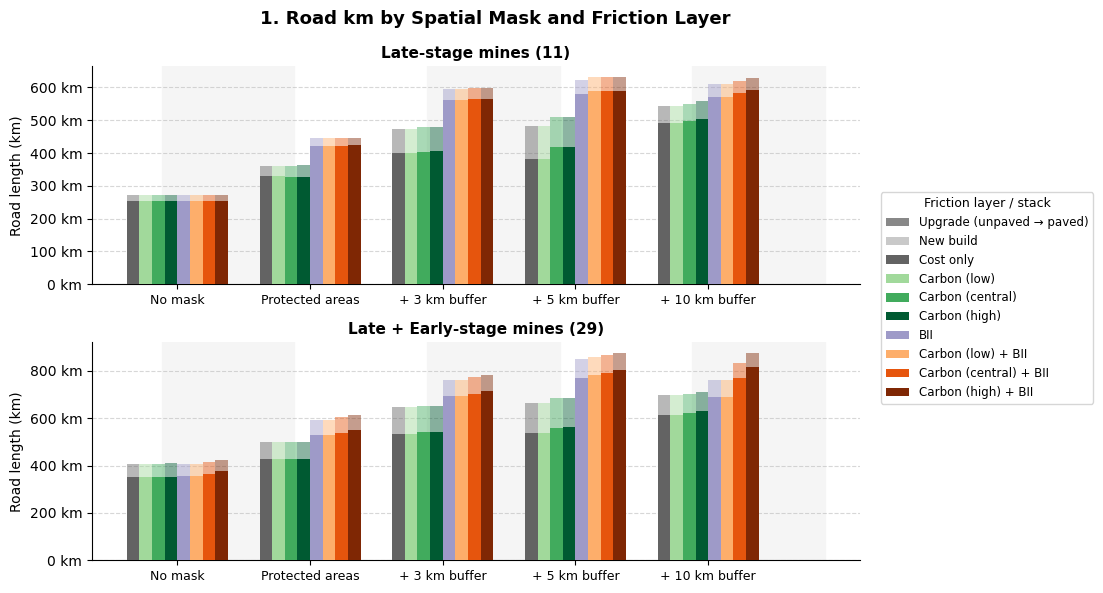

In [34]:
grouped_bar_by_mask(
    col_bottom='unpaved_km', col_top='to_be_built_km',
    label_bottom='Upgrade (unpaved → paved)', label_top='New build',
    ylabel='Road length (km)',
    suptitle='1. Road km by Spatial Mask and Friction Layer',
    fname='fig1_road_km_by_mask.png',
    fmt=lambda v, _: f'{v:.0f} km',
)

## 2. Cost Breakdown by Spatial Mask and Friction Layer

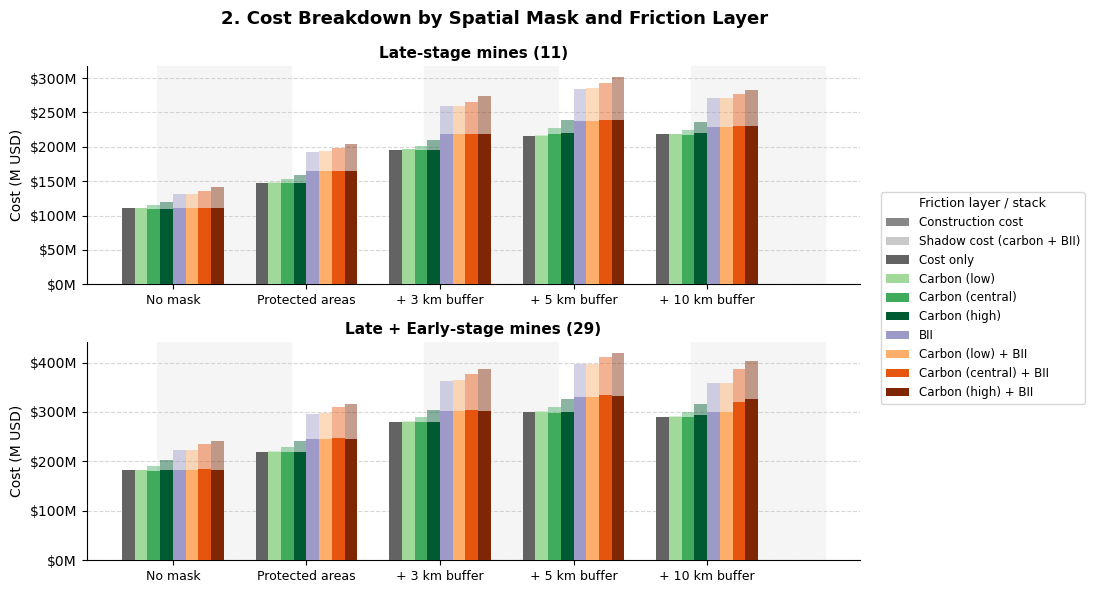

In [35]:
grouped_bar_by_mask(
    col_bottom='construction_cost_musd', col_top='shadow_cost_musd',
    label_bottom='Construction cost', label_top='Shadow cost (carbon + BII)',
    ylabel='Cost (M USD)',
    suptitle='2. Cost Breakdown by Spatial Mask and Friction Layer',
    fname='fig2_cost_by_mask.png',
    fmt=lambda v, _: f'${v:.0f}M',
)

## 3. Deforestation Risk by Spatial Mask and Friction Layer

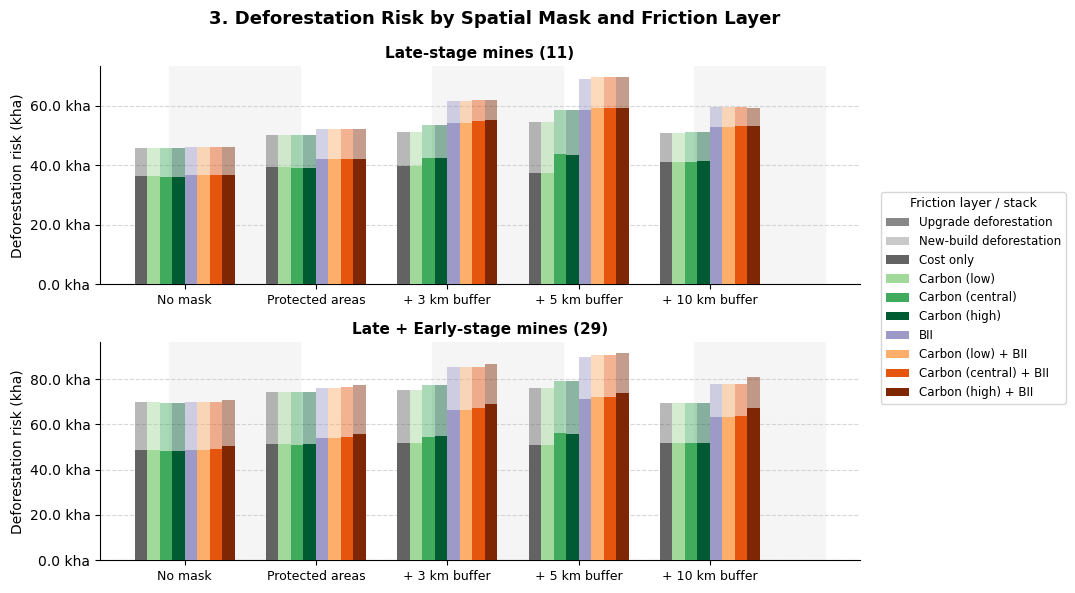

In [36]:
grouped_bar_by_mask(
    col_bottom='defor_upgrade_kha', col_top='defor_build_kha',
    label_bottom='Upgrade deforestation', label_top='New-build deforestation',
    ylabel='Deforestation risk (kha)',
    suptitle='3. Deforestation Risk by Spatial Mask and Friction Layer',
    fname='fig3_deforestation_by_mask.png',
    fmt=lambda v, _: f'{v:.1f} kha',
)

## 4a–4b. Forest Fragmentation by Spatial Mask and Friction Layer

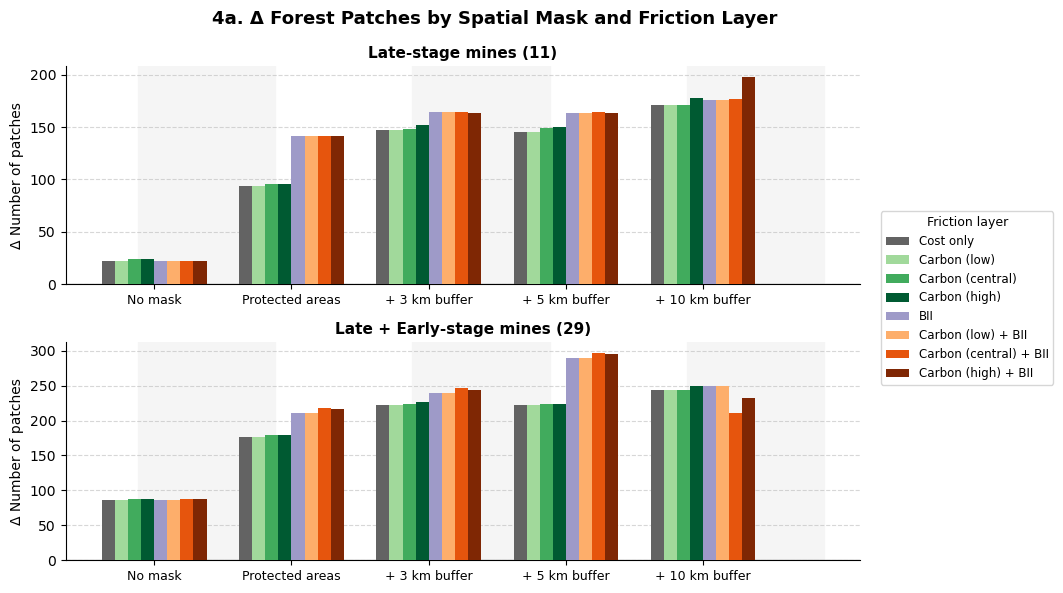

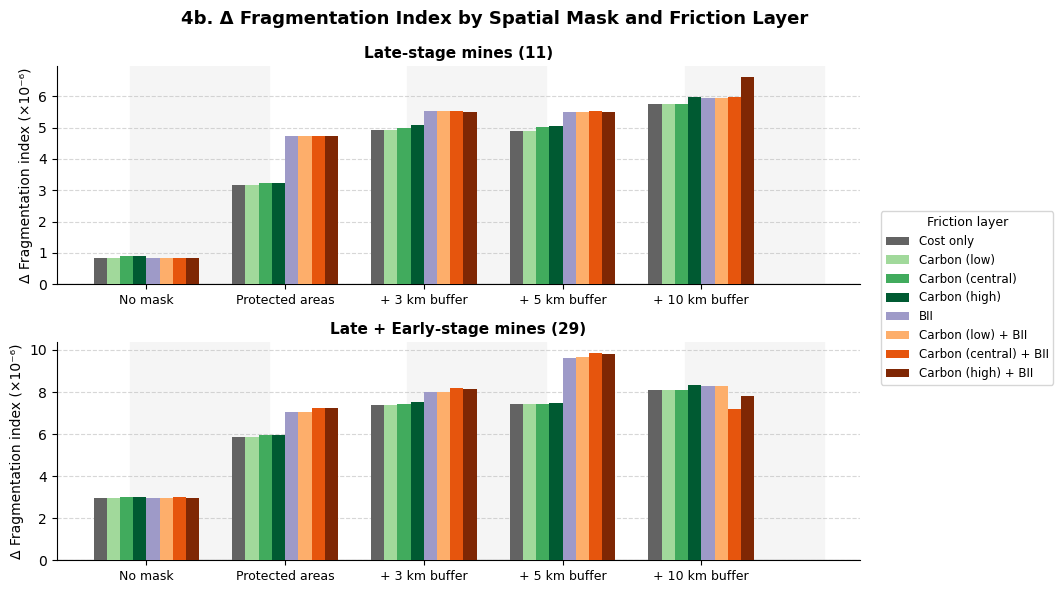

In [37]:
grouped_bar_by_mask(
    col_bottom='frag_delta_n_patches',
    ylabel='Δ Number of patches',
    suptitle='4a. Δ Forest Patches by Spatial Mask and Friction Layer',
    fname='fig4a_delta_patches_by_mask.png',
    zero_line=True,
)

grouped_bar_by_mask(
    col_bottom='delta_fi_e6',
    ylabel='Δ Fragmentation index (×10⁻⁶)',
    suptitle='4b. Δ Fragmentation Index by Spatial Mask and Friction Layer',
    fname='fig4b_delta_frag_index_by_mask.png',
    zero_line=True,
)

## 4c. Accessible Mines per Spatial Mask Buffer

How many mines retain a viable route to port as the spatial mask buffer grows?
Two bars per mask level: late-stage mines (11 total) and late + early-stage mines (29 total).
The count is read from the least-cost-path GeoPackages and is the same across all friction layers
(the mask geometry determines reachability, not the friction values).

Accessible mines per mask:
  Late-stage mines (11): [12, 12, 11, 11, 10]
  Late + Early-stage mines (29): [29, 29, 28, 27, 25]


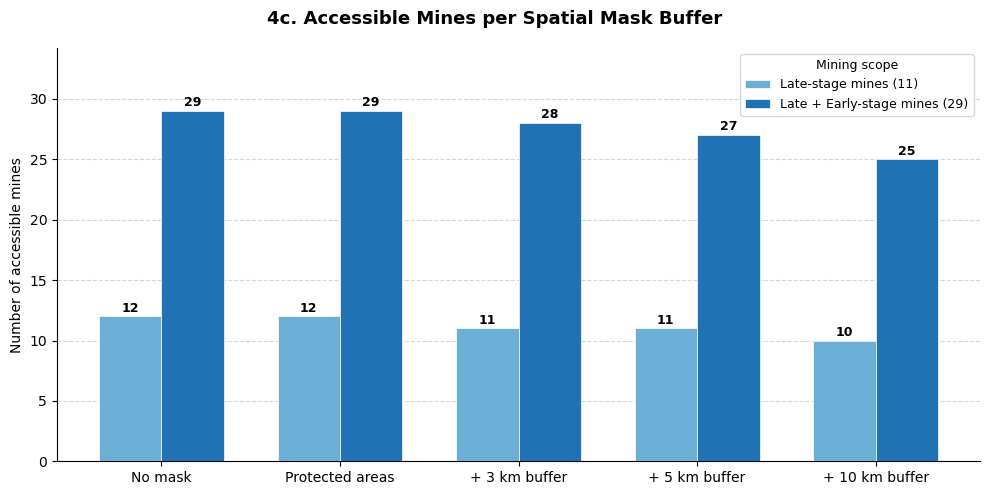

In [38]:
import sqlite3

PATHS_DIR_MINES = Path('../model/results/least-cost-paths/experiment_04_h1')
REF_FRICTION    = 'construction_only'

MINING_BAR_COLORS = {
    'late_stage':           '#6baed6',
    'late_and_early_stage': '#2171b5',
}

def _count_gpkg(fp):
    """Count features in a GeoPackage via SQLite — no geopandas needed."""
    conn = sqlite3.connect(str(fp))
    cur  = conn.execute("SELECT table_name FROM gpkg_contents WHERE data_type='features'")
    row  = cur.fetchone()
    if row is None:
        conn.close()
        return 0
    n = conn.execute(f'SELECT COUNT(*) FROM "{row[0]}"').fetchone()[0]
    conn.close()
    return int(n)

counts = {}
for mining in MINING_ORDER:
    counts[mining] = []
    for mask in MASK_ORDER:
        fp = PATHS_DIR_MINES / f'{mining}__kribi__{REF_FRICTION}__{mask}__ds1.gpkg'
        counts[mining].append(_count_gpkg(fp) if fp.exists() else 0)

print('Accessible mines per mask:')
for m in MINING_ORDER:
    print(f'  {MINING_LABELS[m]}: {counts[m]}')

# ── Plot ───────────────────────────────────────────────────────────────────────
n_masks = len(MASK_ORDER)
bar_w   = 0.35
offsets = np.array([-bar_w / 2, bar_w / 2])
xs      = np.arange(n_masks)

fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle('4c. Accessible Mines per Spatial Mask Buffer', fontsize=13, fontweight='bold')

for mi, mining in enumerate(MINING_ORDER):
    bars = ax.bar(xs + offsets[mi], counts[mining], width=bar_w,
                  color=MINING_BAR_COLORS[mining], label=MINING_LABELS[mining],
                  edgecolor='white', linewidth=0.5, zorder=3)
    for bar, v in zip(bars, counts[mining]):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.15,
                str(v), ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(xs)
ax.set_xticklabels([MASK_LABELS[m] for m in MASK_ORDER], rotation=0, ha='center', fontsize=10)
ax.set_ylabel('Number of accessible mines', fontsize=10)
ax.set_ylim(0, max(max(c) for c in counts.values()) * 1.18)
ax.legend(title='Mining scope', fontsize=9, title_fontsize=9,
          frameon=True, loc='upper right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_axisbelow(True)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig4c_accessible_mines.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Effect of Spatial Mask — Line Plot

For each friction layer, how do key metrics change as the spatial mask buffer grows?
Each line = one friction layer; x-axis = mask buffer level.

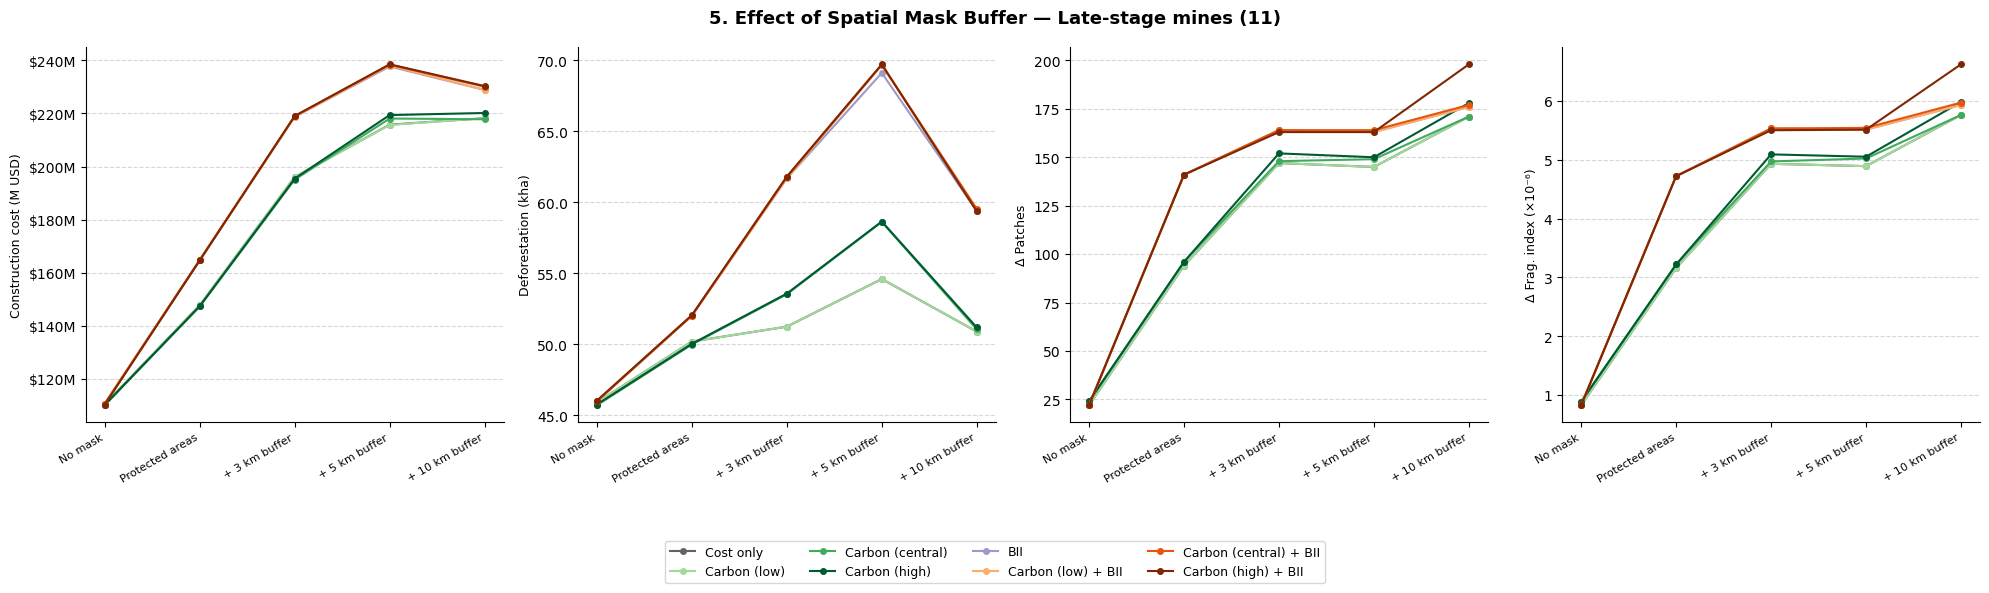

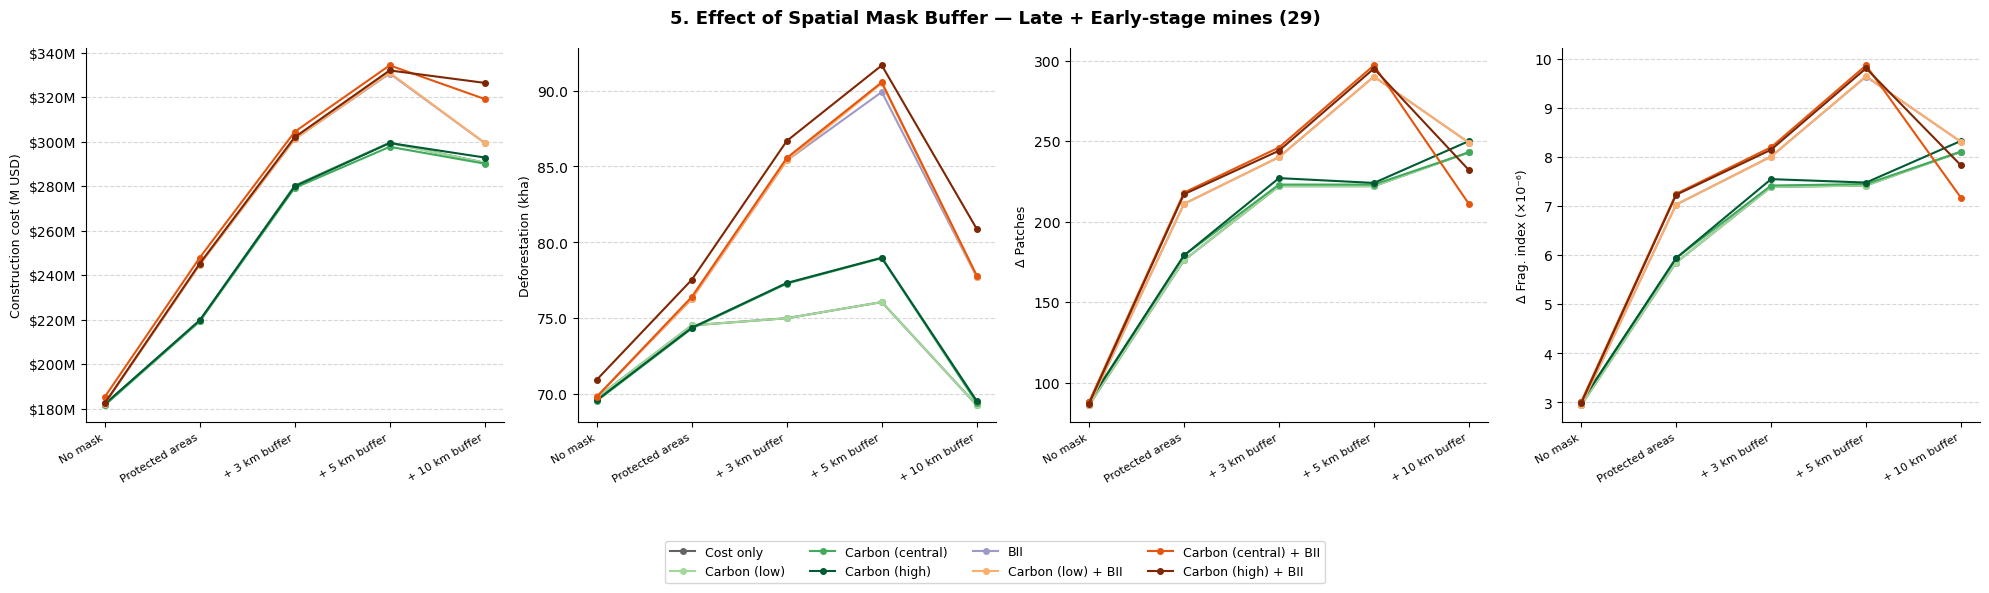

In [28]:
METRICS = [
    ('construction_cost_musd', 'Construction cost (M USD)', lambda v, _: f'${v:.0f}M'),
    ('defor_action_kha',       'Deforestation (kha)',       lambda v, _: f'{v:.1f}'),
    ('frag_delta_n_patches',   'Δ Patches',                 None),
    ('delta_fi_e6',            'Δ Frag. index (×10⁻⁶)',     None),
]

x_ticks  = range(len(MASK_ORDER))
x_labels = [MASK_LABELS[m] for m in MASK_ORDER]

for mining in MINING_ORDER:
    subset = data[data['mining'] == mining]

    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    fig.suptitle(f'5. Effect of Spatial Mask Buffer — {MINING_LABELS[mining]}',
                 fontsize=13, fontweight='bold')

    for ax, (col, ylabel, fmt) in zip(axes, METRICS):
        for friction in FRICTION_ORDER:
            sub = (subset[subset['friction'] == friction]
                   .set_index('mask').reindex(MASK_ORDER))
            ax.plot(x_ticks, sub[col].values,
                    color=FRICTION_COLORS[friction],
                    marker='o', markersize=4, linewidth=1.5,
                    label=FRICTION_LABELS[friction])

        ax.set_xticks(list(x_ticks))
        ax.set_xticklabels(x_labels, rotation=30, ha='right', fontsize=8)
        ax.set_ylabel(ylabel, fontsize=9)
        if fmt:
            ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt))
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.set_axisbelow(True)
        ax.yaxis.grid(True, linestyle='--', alpha=0.5)

    handles = [mlines.Line2D([], [], color=FRICTION_COLORS[f], marker='o',
                             markersize=4, label=FRICTION_LABELS[f])
               for f in FRICTION_ORDER]
    fig.legend(handles=handles, loc='lower center', ncol=4, fontsize=9,
               frameon=True, bbox_to_anchor=(0.5, -0.18))

    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f'fig5_mask_effect_lines__{mining}.png', dpi=150, bbox_inches='tight')
    plt.show()

## 6. Tradeoff: Construction Cost vs. Environmental Impact

Each point = one scenario. Shape = friction layer; color = spatial mask.
Restricted to no_mask for clarity, then shown for all masks.

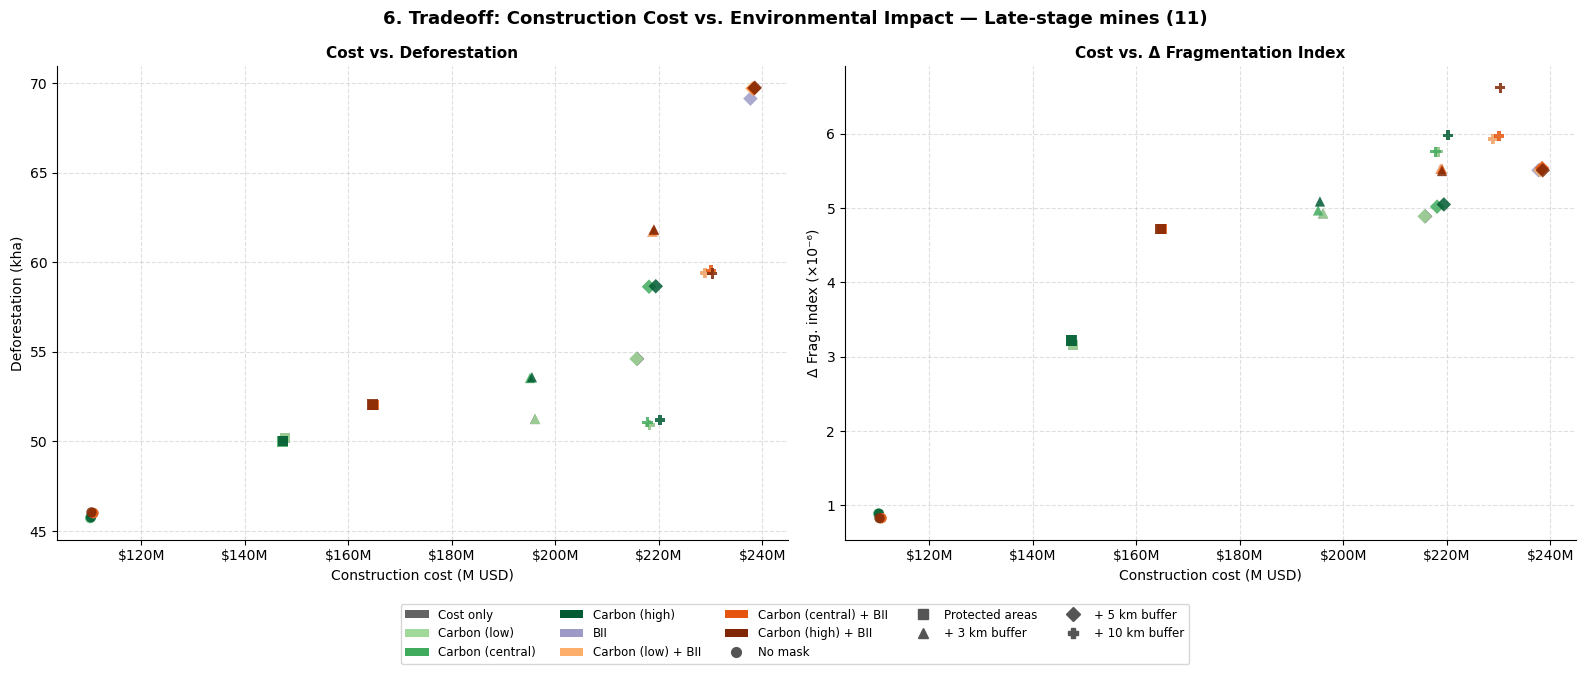

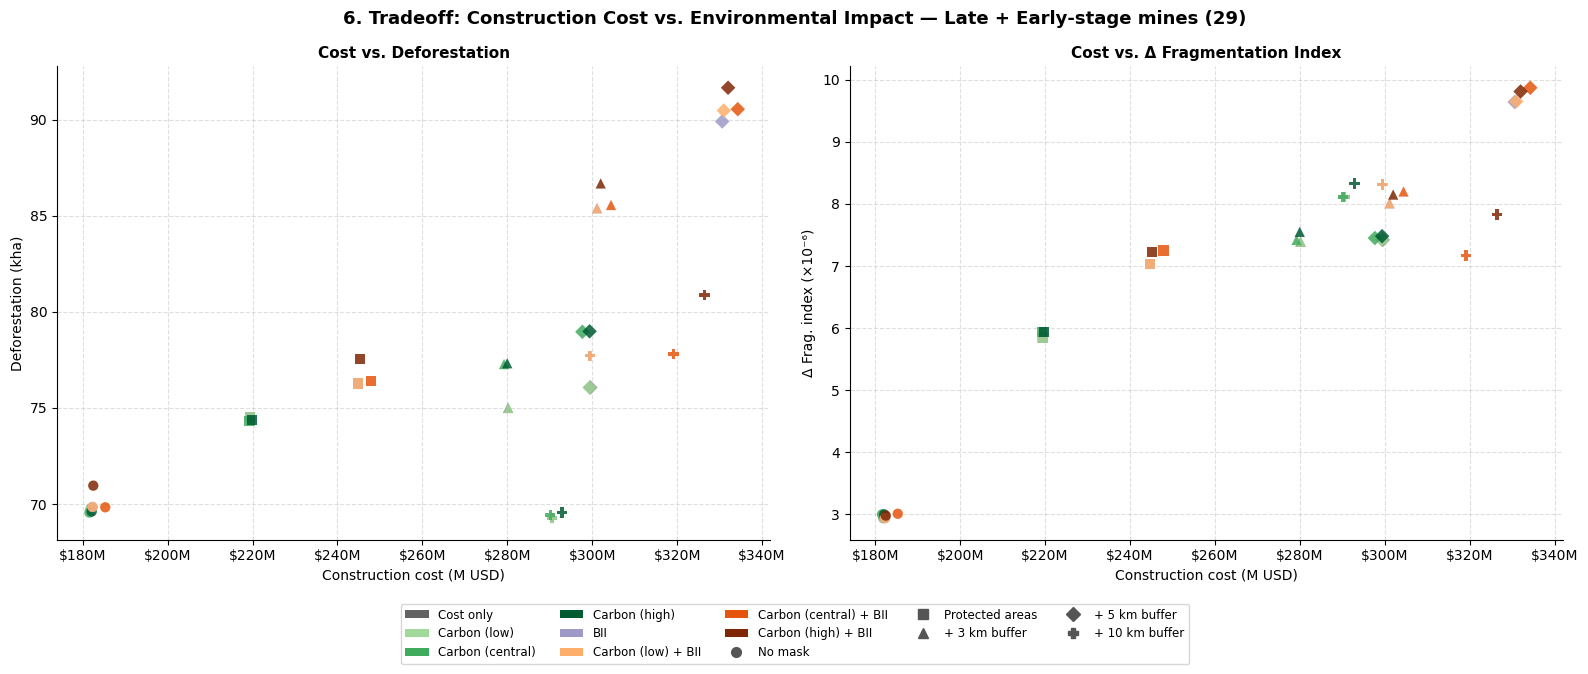

In [29]:
MARKER_SHAPES = {
    'no_mask':                  'o',
    'protected_areas':          's',
    'protected_areas_buf3km':   '^',
    'protected_areas_buf5km':   'D',
    'protected_areas_buf10km':  'P',
}

env_metrics = [
    ('defor_action_kha', 'Deforestation (kha)',   'Cost vs. Deforestation'),
    ('delta_fi_e6',      'Δ Frag. index (×10⁻⁶)', 'Cost vs. Δ Fragmentation Index'),
]

for mining in MINING_ORDER:
    subset = data[data['mining'] == mining]

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f'6. Tradeoff: Construction Cost vs. Environmental Impact — {MINING_LABELS[mining]}',
                 fontsize=13, fontweight='bold')

    for (col, ylabel, title), ax in zip(env_metrics, axes):
        for _, row in subset.iterrows():
            ax.scatter(row['construction_cost_musd'], row[col],
                       color=FRICTION_COLORS[row['friction']],
                       marker=MARKER_SHAPES[row['mask']],
                       s=55, alpha=0.85, zorder=4, edgecolors='none')
        ax.set_xlabel('Construction cost (M USD)', fontsize=10)
        ax.set_ylabel(ylabel, fontsize=10)
        ax.set_title(title, fontweight='bold', fontsize=11)
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:.0f}M'))
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.set_axisbelow(True)
        ax.grid(True, linestyle='--', alpha=0.4)

    fric_handles = [mpatches.Patch(facecolor=FRICTION_COLORS[f], label=FRICTION_LABELS[f])
                    for f in FRICTION_ORDER]
    mask_handles = [mlines.Line2D([], [], color='#555555',
                                  marker=MARKER_SHAPES[m], linestyle='None',
                                  markersize=7, label=MASK_LABELS[m])
                    for m in MASK_ORDER]
    fig.legend(handles=fric_handles + mask_handles,
               loc='lower center', ncol=5, fontsize=8.5,
               frameon=True, bbox_to_anchor=(0.5, -0.12))

    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f'fig6_tradeoff_scatter__{mining}.png', dpi=150, bbox_inches='tight')
    plt.show()

## 7. Spatial Map — Late-Stage Mines, Protected Areas + 3 km Buffer

Generated paths for all 8 friction layers under the same mask (`protected_areas_buf3km`),
late-stage mines only. Blue = upgrade (unpaved → paved), red = new build, gray = existing paved roads.

Paved road segments loaded: 21919
Protected area polygons loaded: 53
Mine locations: 12 (late_stage)
Loaded 8 action-road layers, 8 full-path layers


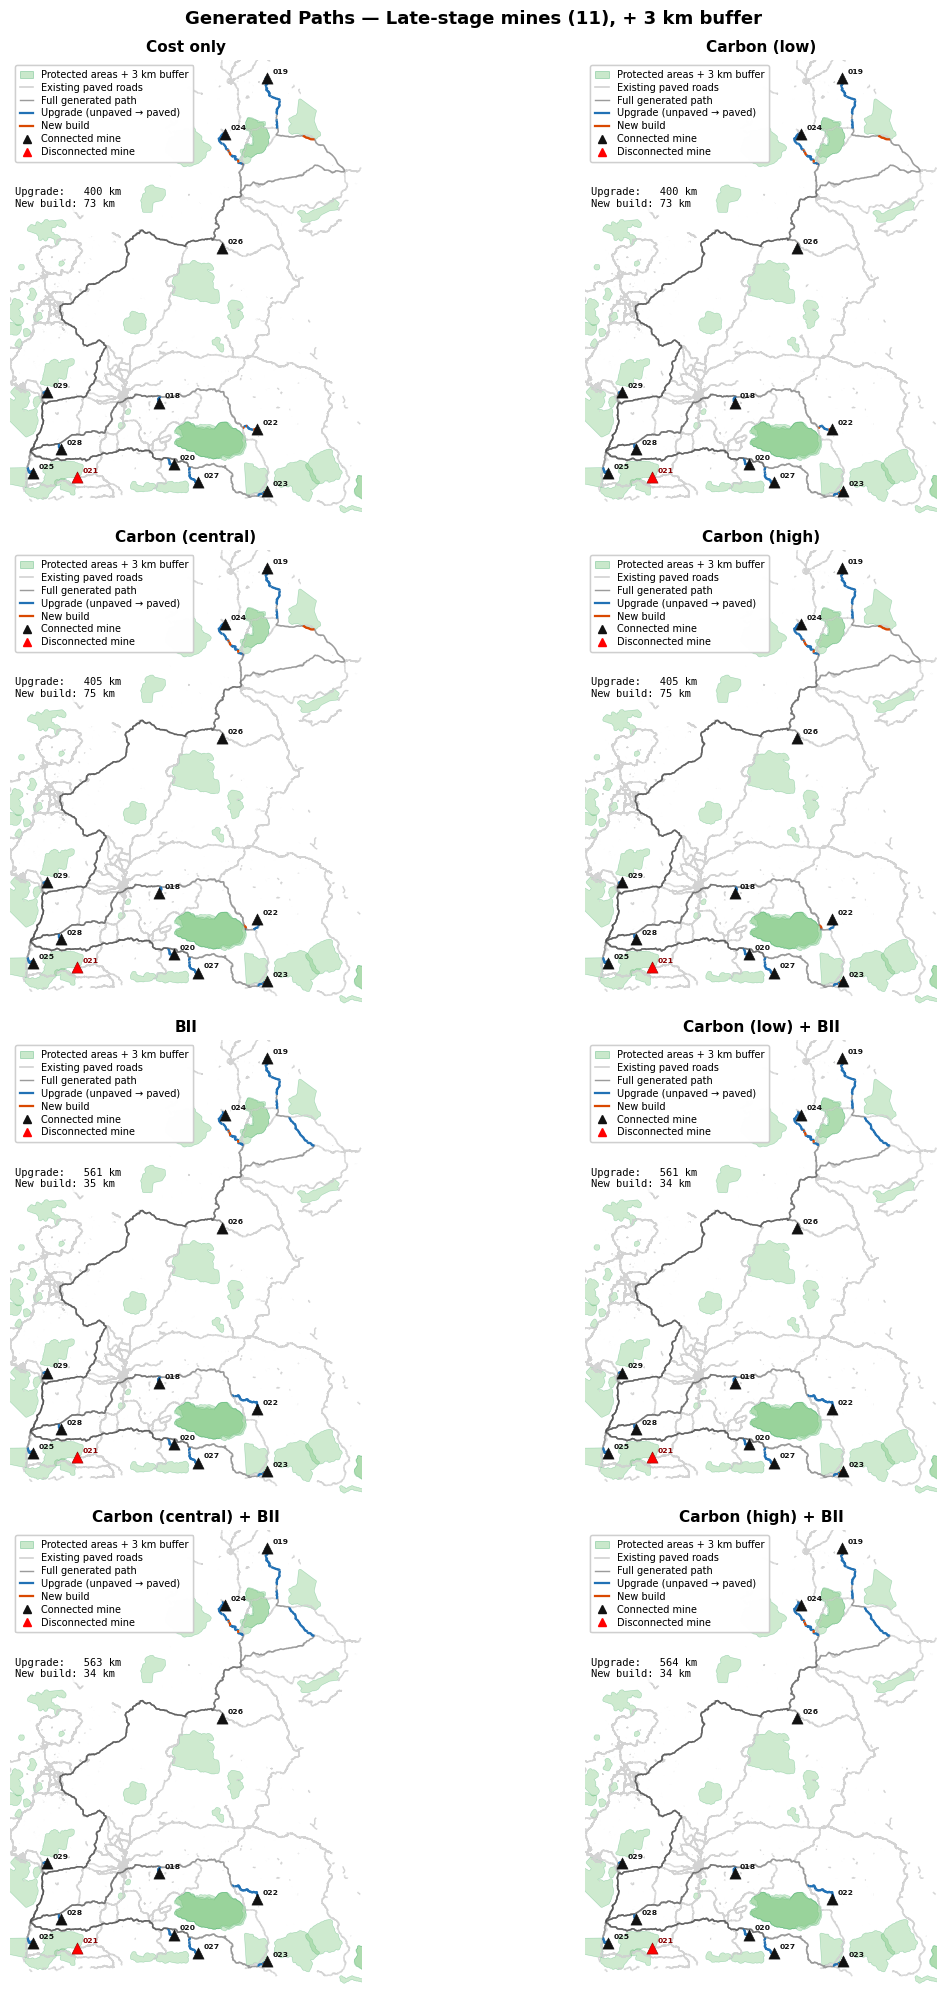

In [41]:
import geopandas as gpd

ROADS_FP    = Path('../data/output/processed_roads_official/cleaned_merged_osm_heigit_liu-ver3-midterm.gpkg')
PATHS_DIR   = Path('../model/results/least-cost-paths/experiment_04_h1')
MINES_FP    = Path('../data/output/cmr-mine-locations/all_mines_with_id.csv')
PA_BUF_FP   = Path('../data/output/processed-protected-areas/with-buffer/cmr-protected-areas__buffer3km.gpkg')
FOCAL_MINING = 'late_stage'
FOCAL_MASK   = 'protected_areas_buf3km'

paved_roads    = gpd.read_file(ROADS_FP).query("liu_surface == 'paved'").to_crs("EPSG:4326")
protected_areas = gpd.read_file(PA_BUF_FP).to_crs("EPSG:4326")
print(f'Paved road segments loaded: {len(paved_roads)}')
print(f'Protected area polygons loaded: {len(protected_areas)}')

# Mine locations for the focal mining scope
mines_df    = pd.read_csv(MINES_FP)
stage_map   = {'late_stage': ['Late-stage'], 'late_and_early_stage': ['Late-stage', 'Early-stage']}
mines_focal = mines_df[mines_df['DEV_STAGE_AGGREGATED_SNL'].isin(stage_map[FOCAL_MINING])].copy()
print(f'Mine locations: {len(mines_focal)} ({FOCAL_MINING})')

# Load action roads
action_gdfs = {}
for fp in sorted(RESULTS_DIR.glob(f'{FOCAL_MINING}__*__{FOCAL_MASK}__*__action_roads.gpkg')):
    parts    = fp.stem.replace('__action_roads', '').split('__')
    friction = '__'.join(parts[2:-2])
    action_gdfs[friction] = gpd.read_file(fp)

# Load full least-cost paths (also provides connected mine IDs via 'mine_id' column)
path_gdfs = {}
for fp in sorted(PATHS_DIR.glob(f'{FOCAL_MINING}__*__{FOCAL_MASK}__*.gpkg')):
    parts    = fp.stem.split('__')
    friction = '__'.join(parts[2:-2])
    path_gdfs[friction] = gpd.read_file(fp)

print(f'Loaded {len(action_gdfs)} action-road layers, {len(path_gdfs)} full-path layers')

# Bounding box from full paths
all_geom = pd.concat(path_gdfs.values())
minx = all_geom.geometry.total_bounds[0] - 0.3
miny = all_geom.geometry.total_bounds[1] - 0.3
maxx = all_geom.geometry.total_bounds[2] + 0.3
maxy = all_geom.geometry.total_bounds[3] + 0.3

# Per-subplot legend handles
subplot_handles = [
    mpatches.Patch(facecolor='#74c476', alpha=0.35, edgecolor='#2ca25f',
                   linewidth=0.6, label='Protected areas + 3 km buffer'),
    mlines.Line2D([], [], color='#d3d3d3', linewidth=1.2, label='Existing paved roads'),
    mlines.Line2D([], [], color='#444444', linewidth=1.0, alpha=0.5, label='Full generated path'),
    mlines.Line2D([], [], color='#2171b5', linewidth=1.6, label='Upgrade (unpaved → paved)'),
    mlines.Line2D([], [], color='#d94801', linewidth=1.6, label='New build'),
    mlines.Line2D([], [], color='#111111', marker='^', markersize=6,
                  linestyle='None', label='Connected mine'),
    mlines.Line2D([], [], color='red',     marker='^', markersize=6,
                  linestyle='None', label='Disconnected mine'),
]

fig, axes = plt.subplots(4, 2, figsize=(14, 20))
fig.suptitle(
    f'Generated Paths — {MINING_LABELS[FOCAL_MINING]}, {MASK_LABELS[FOCAL_MASK]}',
    fontsize=13, fontweight='bold', y=0.995,
)

for idx, friction in enumerate(FRICTION_ORDER):
    r, c = divmod(idx, 2)
    ax   = axes[r][c]

    # Layer 0: protected areas + buffer (background)
    protected_areas.plot(ax=ax, color='#74c476', alpha=0.35,
                         edgecolor='#2ca25f', linewidth=0.4, zorder=0)

    # Layer 1: existing paved roads
    paved_roads.plot(ax=ax, color='#d3d3d3', linewidth=1.0, zorder=1)

    # Layer 2: full least-cost paths
    full_path = path_gdfs.get(friction)
    if full_path is not None:
        full_path.plot(ax=ax, color='#444444', linewidth=1.0, alpha=0.4, zorder=2)

    # Layer 3: action road segments
    gdf = action_gdfs.get(friction)
    if gdf is not None:
        upgrades   = gdf[gdf['action_needed'] == 'upgrade']
        new_builds = gdf[gdf['action_needed'] == 'build']
        if not upgrades.empty:   upgrades.plot(ax=ax,   color='#2171b5', linewidth=1.6, zorder=3)
        if not new_builds.empty: new_builds.plot(ax=ax, color='#d94801', linewidth=1.6, zorder=3)

    # Layer 4: mine pins — black for connected, red for disconnected
    connected_ids = set(full_path['mine_id']) if full_path is not None else set()
    connected_m   = mines_focal[mines_focal['ID'].isin(connected_ids)]
    disco_m       = mines_focal[~mines_focal['ID'].isin(connected_ids)]

    if not connected_m.empty:
        ax.scatter(connected_m['LONGITUDE'], connected_m['LATITUDE'],
                   marker='^', s=65, color='#111111', edgecolors='#111111',
                   linewidths=0.4, zorder=5)
    if not disco_m.empty:
        ax.scatter(disco_m['LONGITUDE'], disco_m['LATITUDE'],
                   marker='^', s=65, color='red', edgecolors='#880000',
                   linewidths=0.4, zorder=5)

    # Mine ID labels
    for _, m_row in mines_focal.iterrows():
        short_id  = m_row['ID'].replace('cmr_', '')
        label_col = '#880000' if m_row['ID'] not in connected_ids else '#111111'
        ax.annotate(short_id,
                    xy=(m_row['LONGITUDE'], m_row['LATITUDE']),
                    xytext=(4, 3), textcoords='offset points',
                    fontsize=5.5, color=label_col, zorder=6,
                    fontweight='bold')

    ax.set_xlim(minx, maxx)
    ax.set_ylim(miny, maxy)
    ax.set_title(FRICTION_LABELS[friction], fontweight='bold', fontsize=11)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)

    # Per-subplot legend (top-left)
    leg = ax.legend(
        handles=subplot_handles,
        loc='upper left',
        fontsize=7,
        framealpha=0.88,
        handlelength=1.4,
        borderpad=0.5,
        labelspacing=0.3,
    )
    ax.add_artist(leg)

    # km stats — placed just below the legend (~72% from bottom)
    row = data[(data['mining'] == FOCAL_MINING) &
               (data['mask']   == FOCAL_MASK)   &
               (data['friction'] == friction)]
    upgrade_km = row['unpaved_km'].values[0]     if not row.empty else float('nan')
    build_km   = row['to_be_built_km'].values[0] if not row.empty else float('nan')
    ax.text(
        0.015, 0.72,
        f'Upgrade:   {upgrade_km:.0f} km\nNew build: {build_km:.0f} km',
        transform=ax.transAxes,
        fontsize=7.5, verticalalignment='top', family='monospace',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.82, edgecolor='none'),
    )

plt.tight_layout()
plt.subplots_adjust(top=0.97)
plt.savefig(FIGURES_DIR / f'fig7_paths_{FOCAL_MINING}_{FOCAL_MASK}.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Incremental Effect

In [40]:
# Mining scope comparison: late_stage (11 mines) → late_and_early_stage (29 mines)
# Compute pairwise % change for each friction × mask combination, then summarise.

late    = data[data['mining'] == 'late_stage'].set_index(['friction', 'mask'])
early   = data[data['mining'] == 'late_and_early_stage'].set_index(['friction', 'mask'])

common  = late.index.intersection(early.index)
late_c  = late.loc[common]
early_c = early.loc[common]

metrics = {
    'Construction cost (M USD)': ('construction_cost_musd', late_c['construction_cost_musd'], early_c['construction_cost_musd']),
    'Deforestation (kha)':       ('defor_action_kha',       late_c['defor_action_kha'],       early_c['defor_action_kha']),
    'Δ Fragmentation index':     ('delta_fi_e6',            late_c['delta_fi_e6'],            early_c['delta_fi_e6']),
    'Δ Patches':                 ('frag_delta_n_patches',   late_c['frag_delta_n_patches'],   early_c['frag_delta_n_patches']),
}

print(f'Comparing {len(common)} matched friction × mask combinations\n')
print(f'{"Metric":<30}  {"Late-stage mean":>18}  {"Late+Early mean":>18}  {"Avg % change":>14}  {"Min %":>8}  {"Max %":>8}')
print('─' * 100)

results = {}
for label, (col, base, comp) in metrics.items():
    pct_change = ((comp - base) / base.abs()) * 100
    results[col] = pct_change
    print(f'{label:<30}  {base.mean():>18.2f}  {comp.mean():>18.2f}  '
          f'{pct_change.mean():>+13.1f}%  {pct_change.min():>+7.1f}%  {pct_change.max():>+7.1f}%')

print()
print('Summary for inline reporting:')
print(f'  Total cost:      avg {results["construction_cost_musd"].mean():+.1f}%')
print(f'  Deforestation:   avg {results["defor_action_kha"].mean():+.1f}%')
print(f'  Frag. index Δ:   avg {results["delta_fi_e6"].mean():+.1f}%')
print(f'  Patch count Δ:   avg {results["frag_delta_n_patches"].mean():+.1f}%')

Comparing 40 matched friction × mask combinations

Metric                             Late-stage mean     Late+Early mean    Avg % change     Min %     Max %
────────────────────────────────────────────────────────────────────────────────────────────────────
Construction cost (M USD)                   185.14              264.53          +45.5%    +30.8%    +67.3%
Deforestation (kha)                          54.48               76.88          +42.0%    +29.8%    +54.1%
Δ Fragmentation index                         4.25                6.78          +93.2%    +18.3%   +262.7%
Δ Patches                                   125.83              202.72         +101.3%    +17.2%   +300.0%

Summary for inline reporting:
  Total cost:      avg +45.5%
  Deforestation:   avg +42.0%
  Frag. index Δ:   avg +93.2%
  Patch count Δ:   avg +101.3%
